In [1]:
import numpy as np
import dill
import pickle
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import glob
import re
import h5py
import pytz
from datetime import datetime, timedelta
import matplotlib.dates as mdates
from zoneinfo import ZoneInfo
from pathlib import Path
import json

In [23]:
import os
import sys

WORKING_DIRECTORY = "/home/beesbook/jacob/bb_local_sync/MAIN/2025/"
os.chdir(WORKING_DIRECTORY)
%load_ext autoreload
%autoreload 2

sys.path.insert(0, "/home/beesbook/jacob/bb_local_sync/MAIN")

import importlib
import definitions_2025 as bd
import bb_metrics.displayfunctions as bp
import bb_metrics.datafunctions as dfunc
importlib.reload(bd)
importlib.reload(bp)
importlib.reload(dfunc)
bp.init(bd)
dfunc.init(bd)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Import comb images to display

In [29]:
comb_background_dir = Path('/mnt/trove/beesbook2025/comb_background/')
annotations_dir = comb_background_dir / "annotations"
annotation_grids_dir = comb_background_dir / "annotation_grids"
label_config_path = Path("/home/beesbook/jacob/bb_local_sync/MAIN/bb_metrics/config/label_classes.json")


In [30]:
background_files_df, annotation_files_df, combined_df = dfunc.build_combined_annotation_df(
    comb_background_dir,
    bd.cam_hive_map,
)
combined_df


,path,cam,hive,timestamp,day,image_key,annotation_path,is_annotated
0,/mnt/trove/beesbook2025/comb_background/cam-0/...,0,A,2025-06-13 07:51:49+00:00,2025-06-13 00:00:00+00:00,background_cam-0_20250613T075149.775333.323Z,NaN,False
1,/mnt/trove/beesbook2025/comb_background/cam-0/...,0,A,2025-06-14 08:44:56+00:00,2025-06-14 00:00:00+00:00,background_cam-0_20250614T084456.555811.256Z,NaN,False
2,/mnt/trove/beesbook2025/comb_background/cam-0/...,0,A,2025-06-15 08:46:47+00:00,2025-06-15 00:00:00+00:00,background_cam-0_20250615T084647.689669.826Z,NaN,False
3,/mnt/trove/beesbook2025/comb_background/cam-0/...,0,A,2025-06-16 08:48:39+00:00,2025-06-16 00:00:00+00:00,background_cam-0_20250616T084839.294967.726Z,NaN,False
4,/mnt/trove/beesbook2025/comb_background/cam-0/...,0,A,2025-06-17 09:32:35+00:00,2025-06-17 00:00:00+00:00,background_cam-0_20250617T093235.60434.93Z,NaN,False
...,...,...,...,...,...,...,...,...
498,/mnt/trove/beesbook2025/comb_background/cam-7/...,7,D,2025-08-13 05:38:25+00:00,2025-08-13 00:00:00+00:00,background_cam-7_20250813T053825.608051.116Z,NaN,False
499,/mnt/trove/beesbook2025/comb_background/cam-7/...,7,D,2025-08-14 05:55:29+00:00,2025-08-14 00:00:00+00:00,background_cam-7_20250814T055529.868693.529Z,NaN,False
500,/mnt/trove/beesbook2025/comb_background/cam-7/...,7,D,2025-08-15 13:14:19+00:00,2025-08-16 00:00:00+00:00,background_cam-7_20250815T131419.87692.053Z,/mnt/trove/beesbook2025/comb_background/annota...,True
501,/mnt/trove/beesbook2025/comb_background/cam-7/...,7,D,2025-08-16 13:16:05+00:00,2025-08-17 00:00:00+00:00,background_cam-7_20250816T131605.604246.837Z,NaN,False


## Which days are annotated?

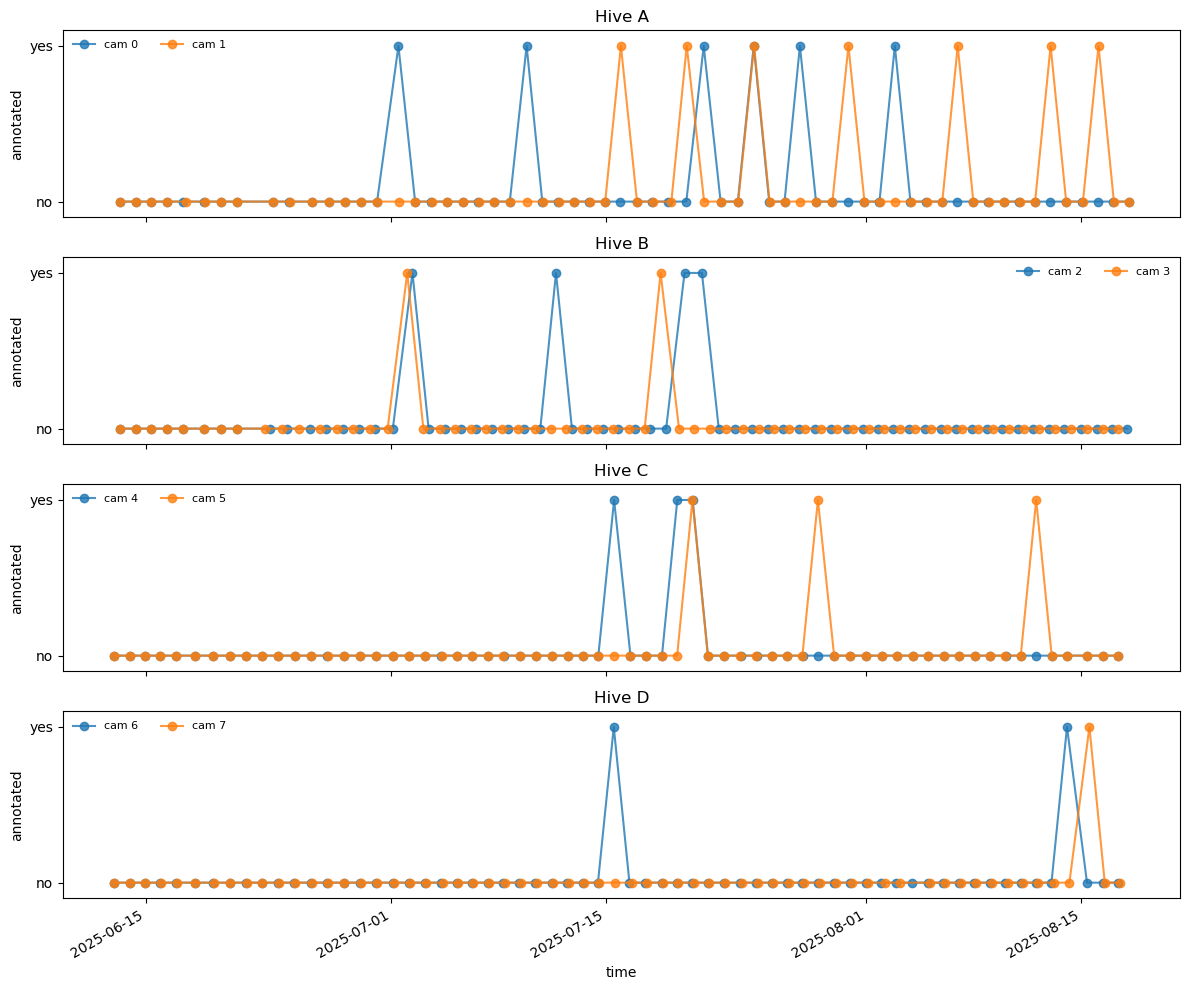

In [31]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plot_df = combined_df.sort_values(["hive", "cam", "timestamp"]).copy()
plot_df["is_annotated_num"] = plot_df["is_annotated"].astype(int)

hives = sorted(plot_df["hive"].dropna().unique())
fig, axes = plt.subplots(
    nrows=len(hives),
    ncols=1,
    figsize=(12, 2.5 * len(hives)),
    sharex=True,
    sharey=True,
)

if len(hives) == 1:
    axes = [axes]

for ax, hive in zip(axes, hives):
    hive_df = plot_df[plot_df["hive"] == hive]
    for cam, group in hive_df.groupby("cam"):
        ax.plot(
            group["timestamp"],
            group["is_annotated_num"],
            marker="o",
            linestyle="-",
            label=f"cam {cam}",
            alpha=0.8,
        )
    ax.set_title(f"Hive {hive}")
    ax.set_ylim(-0.1, 1.1)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["no", "yes"])
    ax.set_ylabel("annotated")
    ax.legend(ncol=2, fontsize=8, frameon=False)

axes[-1].set_xlabel("time")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


## Visualize 

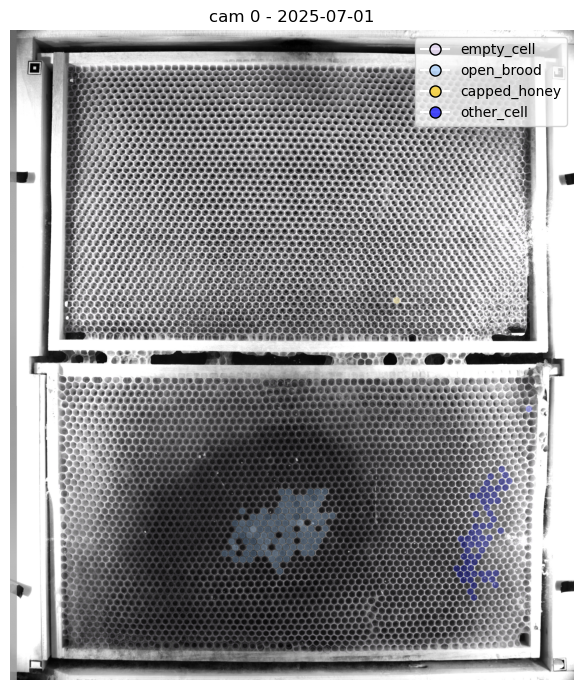

KeyboardInterrupt: 

In [18]:
label_color_hex, label_order, keep_labels, other_label = dfunc.load_label_config(label_config_path)

annotated_df = combined_df[combined_df["is_annotated"]].copy()
for idx, row in annotated_df.iterrows():
    dfunc.plot_annotated_row(
        row,
        label_color_hex,
        label_order,
        keep_labels,
        other_label,
        alpha_fill=0.25,
        alpha_edge=0.1,
        fill_empty_cell=False,
        empty_label="empty_cell",
        rotate_clockwise=True,
        cmap="gray",
        figsize=(10, 7),
    )





# Downsampled image grid with labels

## calculate and save for all images

In [34]:
# ---- Runner: compute all grids (serial) ----
label_color_hex, label_order, keep_labels, other_label = dfunc.load_label_config(label_config_path)

annotated_df = combined_df[combined_df["is_annotated"]].copy()
annotation_paths = annotated_df["annotation_path"].astype(str).tolist()

# bd.xpixels/ypixels are rotated; raw dims are swapped
raw_w = int(bd.ypixels)
raw_h = int(bd.xpixels)

ds = 8
output_dir = annotation_grids_dir
recalc = True

results = []
for p in annotation_paths:
    results.append(
        dfunc.process_one_annotation(
            p,
            output_dir,
            raw_w,
            raw_h,
            ds,
            label_order,
            keep_labels,
            other_label,
            recalc,
        )
    )

results[:5]


[('/mnt/trove/beesbook2025/comb_background/annotation_grids/06_background_cam-0_20250701T112749.804969.329Z_ds_8.npz',
  'saved'),
 ('/mnt/trove/beesbook2025/comb_background/annotation_grids/07_background_cam-0_20250709T200757.484143.445Z_ds_8.npz',
  'saved'),
 ('/mnt/trove/beesbook2025/comb_background/annotation_grids/08_background_cam-0_20250721T092330.666153.741Z_ds_8.npz',
  'saved'),
 ('/mnt/trove/beesbook2025/comb_background/annotation_grids/09_background_cam-0_20250724T154106.711638.646Z_ds_8.npz',
  'saved'),
 ('/mnt/trove/beesbook2025/comb_background/annotation_grids/10_background_cam-0_20250727T155919.129984.261Z_ds_8.npz',
  'saved')]

## How to use

In [36]:
from pathlib import Path
import pandas as pd

# Build metadata table that maps cam+timestamp -> grid file
grid_dir = annotation_grids_dir
ds = 8

ann_df = dfunc.build_grid_metadata_df(combined_df, grid_dir, ds)
ann_df["grid_path"] = ann_df["grid_path"].astype(str)
ann_df.to_parquet(grid_dir / f"annotation_grids_ds_{ds}.parquet", index=False)

# Example usage
grid_lookup = dfunc.GridLookup(ann_df)
label = grid_lookup.lookup_label(cam=0, timestamp="2025-07-01T12:00:00Z", x=100, y=2200)
label




'empty_cell'